100%|██████████| 1296/1296 [00:00<00:00, 94084.36it/s]


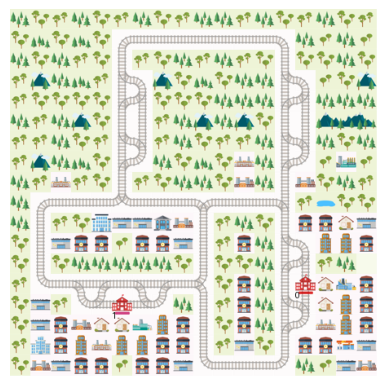

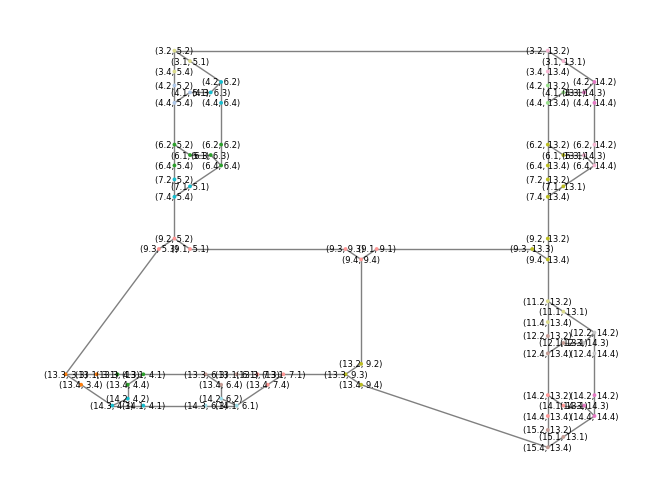

52
0.06334803899517283


In [ ]:
import functools
import logging
from abc import ABC, abstractmethod
from collections import OrderedDict
from typing import Any, Dict, List, Tuple, Type

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from flatland.envs.agent_utils import EnvAgent as TrainAgent
from flatland.envs.line_generators import sparse_line_generator
from flatland.envs.rail_env import RailEnv, RailEnvActions
from flatland.envs.rail_generators import sparse_rail_generator
from flatland.envs.step_utils.env_utils import apply_action_independent
from flatland.utils.rendertools import AgentRenderVariant
from gymnasium import spaces
from gymnasium.spaces import MultiDiscrete, Space
from pettingzoo import AECEnv

from environment.utils.rail_graph import (
    add_rail_actions,
    create_rail_graph,
    generate_local_switch_graphs,
    insert_switch_proximity_nodes,
    prune_non_switches,
)
from environment.utils.switch_agent import build_rail_action_map

rail_env = RailEnv(
    width=18,
    height=18,
    rail_generator=sparse_rail_generator(
        max_num_cities=5,
        grid_mode=True,
        max_rails_between_cities=1,
        max_rail_pairs_in_city=1,
        seed=41,
    ),
    line_generator=sparse_line_generator(),
    number_of_agents=2,
)

NodeId = Tuple[int, int]
PortId = Tuple[float, float]
SwitchId = str  # switch_(x, y)
SwitchPosition = Tuple[int, int]
TrainAgentHandle = int


class TargetSpace(MultiDiscrete):
    def __init__(self, height: int, width: int, n_ports: int, seed: int = None):
        # Ranges: [-1, height -1] and [-1, width -1] for each (x, y) pair
        # Offsets: we shift everything up by 1 to fit MultiDiscrete which only supports lower bound = 0
        nvec = np.array(
            [[height + 1, width + 1]] * n_ports
        )  # +1 for including -1 and height/width-1
        super().__init__(nvec=nvec.flatten(), seed=seed)  # flatten to shape (6,)

        self.height = height
        self.width = width
        self.n_ports = n_ports

    def sample(self):
        # Shift down by 1 to account for offset applied in nvec
        raw_sample = super().sample().reshape(self.n_ports, 2)
        return raw_sample - 1  # Undo the -1 shift

    def contains(self, x):
        x = np.array(x)
        if x.shape != (self.n_ports, 2):
            return False
        return np.all((-1 <= x) & (x[:, 0] <= self.height) & (x[:, 1] <= self.width))

    @property
    def is_np_flattenable(self) -> bool:
        """Checks whether this space can be flattened to a :class:`gymnasium.spaces.Box`."""
        return True

    def human_format(self, sample: np.ndarray) -> Dict[str, np.ndarray]:
        assert self.contains(sample)
        return {"train_targets": sample}


class MultiDiscreteSwitchObsSpace(Space):
    def __init__(
        self,
        n_gaits: int,
        rail_grid_shape: Tuple[int, int],
        n_delay_levels: int = 3,
        seed=None,
    ):
        n_dims = n_gaits + (n_gaits * 2) + n_gaits
        shape = (n_dims,)
        dtype = int
        super().__init__(shape, dtype, seed)

        self.n_gaits = n_gaits  # how many rails are connected to a node -> Binary variable: is one occupied or not
        self.rail_grid_shape = rail_grid_shape
        self.n_delay_levels = n_delay_levels

        self.station_space = TargetSpace(
            height=self.rail_grid_shape[0], width=self.rail_grid_shape[1], seed=seed
        )

        self.delay_space = spaces.MultiDiscrete(
            np.ones(self.n_gaits) * (self.n_delay_levels + 1),
            seed=seed,
            start=np.ones(self.n_gaits) * (-1),
        )
        # of a rail is blocked or if a train can be send onto this rail
        self.semaphore_space = spaces.MultiDiscrete(
            np.ones(n_gaits) * 2,
            seed=seed,
            start=np.zeros(n_gaits),
        )

    def sample(self):
        sample = np.concatenate(
            [
                self.semaphore_space.sample(),
                self.station_space.sample().flatten(),
                self.delay_space.sample(),
            ]
        )
        return sample

    def contains(self, x):
        x = np.array(x)
        if x.shape != self._shape:
            return False
        # break it up
        if not self.semaphore_space.contains(x[: self.semaphore_space.shape[0]]):
            return False
        if not self.station_space.contains(
            x[
                self.semaphore_space.shape[0] : self.semaphore_space.shape[0]
                + np.prod(self.station_space.shape)
            ]
        ):
            return False
        if not self.delay_space.contains(x[-self.delay_space.shape[0] :]):
            return

        return True

    @property
    def is_np_flattenable(self) -> bool:
        """Checks whether this space can be flattened to a :class:`gymnasium.spaces.Box`."""
        return True

    def human_format(self, sample: np.ndarray) -> Dict[str, np.ndarray]:
        assert self.contains(sample)
        return {"train_targets": sample}


def build_switch_to_rail_actions(
    switch_graph: nx.Graph,
) -> Tuple[List[Dict[Any, List[RailEnvActions]]], List[Tuple[Any, Any]]]:
    """returns a list of actions for each port.

    Args:
        switch_graph (nx.Graph): switch graph with ports and inter-connectivity's

    Returns:
        Tuple[List[Dict[Any, List[RailEnvActions]]], List[Any, Any]]: Each entry in the parent list corresponds to one action
            1. List[Dict[Any, List[RailEnvActions]]]: each entry contains commands for trains at each port of the switch
            2. List[Any, Any]: After executing, across which ports will the train transition the switch (source, target)
    """
    # add actions to switch_graph
    switch_graph = add_rail_actions(switch_graph)
    action_map, outcomes = build_rail_action_map(switch_graph)
    return action_map, outcomes


class _Switch(ABC):
    def __init__(
        self,
        id: NodeId,
        switch_graph: nx.Graph,
        port2neighbor: Dict[PortId, NodeId] = None,
    ):
        self.id = id
        self.switch_graph = switch_graph
        self.port2neighbor = port2neighbor

        self.n_gaits = len(self.switch_graph.nodes)
        self.n_rails = len(self.switch_graph.edges)

        ab = build_switch_to_rail_actions(self.switch_graph)
        self.actions = ab[0]
        """List of actions per port: self.actions[z]: 2 actions per port"""
        self.action_outcomes = ab[1]
        """List of port mappings. self.action_outcomes[z]: train from port x to port y"""

        self.semaphores: Dict[PortId, bool] 
        """which ports are blocked: True, which are free: False"""
        self._port_nodes = OrderedDict(
            {int(str(node[0])[-1]): node for node in self.switch_graph.nodes}
        )
        """to have a ordered list of port nodes"""
        self._pos2port: Dict[Tuple[int, int], PortId] = {
            pos: port for port, pos in self.switch_graph.nodes.data("rail_prev_node")
        }
        """rail position before entering a node"""
        
        self.reset()
        
    def reset(self):
        self.semaphores = {port: False for port in self.switch_graph.nodes}

    def block_port(self, port: PortId):
        """indicate a given port is blocked because of an incoming train

        Args:
            port (PortId): which port is blocked
        """
        if port not in self.semaphores.keys():
            logging.error(f"{port=} is not part of switch:{self.id}")
            return
        self.semaphores[port] = True

    def free_port(self, port: PortId):
        """indicate a given port is freed because of an incoming train is already processed

        Args:
            port (PortId): which port is freed
        """
        if port not in self.semaphores.keys():
            logging.error(f"{port=} is not part of switch:{self.id}")
            return
        self.semaphores[port] = False

    def get_action_mask(self) -> np.ndarray:
        """which actions are allowed wrt. incoming train semaphores

        Returns:
            np.ndarray: integer array. 1: action allowed, 0: action forbidden (n_actions, )
        """
        mask = [self.semaphores[target] for _, target in self.action_outcomes]
        mask = (~np.array(mask)).astype(np.int8)
        return mask

    def get_train_action(
        self, action: int, train_agents: List[TrainAgent]
    ) -> Dict[TrainAgentHandle, List[RailEnvActions]]:
        """For the given trains which are about to enter this switch, return the actions sequences for each train

        Args:
            action (int): discrete action
            train_agents (List[TrainAgent]): all trains on the grid

        Returns:
            Dict[TrainAgentHandle, List[RailEnvActions]]: For each train at the switch return actions to perform
        """
        _, target_port = self.action_outcomes[action]
        if self.semaphores[target_port]:
            raise RuntimeError(
                f"Semaphore is blocked for action: {self.action_outcomes[action]}"
            )

        result = {}
        for train_agent in train_agents:
            port_node = self._pos2port.get(train_agent.position)
            if port_node is None:
                # train is not at a port node
                continue
            result[train_agent.handle] = self.actions[action][port_node]

        # If only one train and it is STOP_MOVING
        if (
            len(result) == 1
            and next(iter(result.values()))[0] == RailEnvActions.STOP_MOVING
        ):
            result[next(iter(result))] = [RailEnvActions.STOP_MOVING]
        return result

    def get_port_nodes(self) -> List[PortId]:
        return list(self._port_nodes.values())

    @abstractmethod
    def get_action_space(self, seed: int = None) -> Space:
        raise NotImplementedError


# T or Y junction
class Switch1(_Switch):
    def __init__(self, id, switch_graph, port2neighbor=None):
        super().__init__(id, switch_graph, port2neighbor)

    def get_action_space(self, seed=None):
        # gaits: 0, 1, 2
        # switch gait: 3
        # 0  1  2
        # --------
        # g  w  w
        # w  g  w
        # w  w  g1
        # w  w  g2
        # can have a different permutation based on orientation
        return spaces.Discrete(4, seed=seed)


# Intersection
class Switch2(_Switch):
    def __init__(self, id, switch_graph, port2neighbor=None):
        super().__init__(id, switch_graph, port2neighbor)

    def get_action_space(self, seed=None):
        # gaits: 0, 1, 2, 3
        # switch gait: None
        # 0  1  2  3
        # ----------
        # g  w  g  w
        # w  g  w  g
        return spaces.Discrete(2, seed=seed)


# Intersection with one pass
class Switch3(_Switch):
    def __init__(self, id, switch_graph, port2neighbor=None):
        super().__init__(id, switch_graph, port2neighbor)

    def get_action_space(self, seed=None):
        # gaits: 0, 1, 2, 3
        # switch gait: 0, 3
        # 0  1  2  3
        # ----------
        # g1 w  w  w
        # g2 w  w  w
        # w  g  w  w
        # w  w  g  w
        # w  w  w  g1
        # w  w  w  g2
        return spaces.Discrete(6, seed=seed)


# Intersection with two passes
class Switch4(_Switch):
    def __init__(self, id, switch_graph, port2neighbor=None):
        super().__init__(id, switch_graph, port2neighbor)

    def get_action_space(self, seed=None):
        # gaits: 0, 1, 2, 3
        # switch gait: 0, 1, 2, 3
        # 0  1  2  3
        # ----------
        # g1 w  w  w
        # g2 w  w  w
        # w  g1 w  w
        # w  g2 w  w
        # w  w  g1 w
        # w  w  g2 w
        # w  w  w  g1
        # w  w  w  g2
        return spaces.Discrete(8, seed=seed)


SWITCH_AGENT_MAP = {
    (3, 2): Switch1,
    (4, 2): Switch2,
    (4, 3): Switch3,
    (4, 4): Switch4,
}


def get_switch_type(switch_graph: nx.Graph) -> Type[_Switch]:
    n_gaits = len(switch_graph.nodes)
    n_rails = len(switch_graph.edges)
    try:
        return SWITCH_AGENT_MAP[(n_gaits, n_rails)]
    except KeyError:
        raise ValueError(f"No Agent with {n_gaits=} and {n_rails=}")


def plot_rail_network(rail_graph: nx.Graph):
    nx.draw(
        rail_graph.to_undirected(),
        rail_graph.nodes.data("position"),
        with_labels=True,
        node_color=dict(rail_graph.nodes.data(data="node_color")).values(),
        edge_color="gray",
        node_size=3,
        font_size=6,
    )
    plt.show()


def build_switch_network(rail_network: nx.Graph) -> nx.Graph:
    switch_network = nx.Graph()
    df = pd.DataFrame(
        [attr for _, attr in rail_network.nodes.data()],
        index=[idx for idx, _ in rail_network.nodes.data()],
    )
    edges = set()
    for node, attr in df.groupby("switch_id"):
        switch_graph = rail_network.subgraph(attr.index)

        # find neighbors for edges
        port2neighbor = {}
        for port in switch_graph.nodes:
            neighbors = rail_network.neighbors(port)
            neighbor_port_df = df[df.index.isin(neighbors) & (df["switch_id"] != node)]
            edges.add((node, neighbor_port_df["switch_id"].item()))
            port2neighbor[port] = neighbor_port_df["switch_id"].item()

        switch = get_switch_type(switch_graph)(node, switch_graph, port2neighbor)

        switch_network.add_node(
            node,
            switch_cls=switch,
            node_color=attr["node_color"].iloc[0],
            position=(node[1], -node[0]),
        )

    switch_network.add_edges_from(edges)
    return switch_network


def build_rail_graph(rail_env: RailEnv) -> nx.Graph:
    rail_env.reset()
    graph = create_rail_graph(rail_env)
    graph = insert_switch_proximity_nodes(graph)
    graph = prune_non_switches(graph)
    graph = generate_local_switch_graphs(graph)
    return graph


def get_node_id_on_port_id(port_id: PortId) -> NodeId:
    return (int(port_id[0]), int(port_id[1]))


def switch_id2name(switch_id: NodeId) -> str:
    name = f"{switch_id[0]}-{switch_id[1]}"
    name = "switch_" + name
    return name


def name2switch_id(name: str) -> NodeId:
    node_id = name.split("_")[1].split("-")
    node_id = (int(node_id[0]), int(node_id[1]))
    return node_id


class RailNetwork:
    def __init__(self, rail_env: RailEnv):
        self.switch_network: nx.Graph

        self.rail_graph = build_rail_graph(rail_env)
        self.switch_network = build_switch_network(self.rail_graph)

        # build lookup dictionaries
        self._pos2port: Dict[Tuple[int, int], PortId] = {
            pos: port for port, pos in self.rail_graph.nodes.data("rail_prev_node")
        }
        """rail position before entering a node"""
        self._pos2switch: Dict[Tuple[int, int], _Switch] = {
            switch_node: switch
            for switch_node, switch in self.switch_network.nodes.data("switch_cls")
        }
        """switch position to switch class"""
        
    def reset(self):
        # reset all switches
        for node, switch in self.switch_network.nodes.data("switch_cls"):
            switch: _Switch
            switch.reset()
        

    def get_switch_on_position(self, switch: NodeId) -> _Switch | None:
        """get switch class for the corresponding position of the switch

        Args:
            switch (NodeId): position in rail grid

        Returns:
            _Switch | None: if given node does not belong to a switch return None. Otherwise the switch object
        """
        if switch not in self.switch_network.nodes:
            return None
        return self.switch_network.nodes.data("switch_cls")[switch]

    def get_neighbor_switch(self, port: PortId) -> _Switch:
        node_id = get_node_id_on_port_id(port)
        switch = self.get_switch_on_position(node_id)
        neighbor_node_id = switch.port2neighbor[port]
        neighbor_switch = self.get_switch_on_position(neighbor_node_id)
        return neighbor_switch

    def get_switch_on_port(self, port: PortId) -> _Switch:
        """get the switch if the position is a node before entering a switch node

        Args:
            position (PortId): position in rail network

        Returns:
            _Switch | None: either a switch or None, if the given position does not belong to a switch
        """
        node_id = get_node_id_on_port_id(port)
        return self._pos2switch[node_id]

    def get_port_on_position(self, position: Tuple[int, int]) -> PortId | None:
        """get the port node if the position is a node before entering a switch node

        Args:
            position (Tuple[int, int]): position in rail network

        Returns:
            PortId | None: either a port or None, if the given position does not belong to a switch
        """
        return self._pos2port.get(position)

    def free_semaphore(self, port: PortId):
        switch = self.get_switch_on_port(port)
        switch.free_port(port)
        node_id = get_node_id_on_port_id(port)
        self.switch_network.update(nodes={node_id: {"switch_cls": switch}})

    def block_semaphore(self, port: PortId):
        switch = self.get_switch_on_port(port)
        switch.block_port(port)
        node_id = get_node_id_on_port_id(port)
        self.switch_network.update(nodes={node_id: {"switch_cls": switch}})

    def transition_semaphore(self, source: PortId, target: PortId):
        self.free_semaphore(source)
        self.block_semaphore(target)

        # account for the case where the next switch is a simple intersections.
        # In this case also the next semaphores have to be switched on
        if isinstance(self.get_neighbor_switch(target), Switch2):
            # find the next switch after this one
            # TODO
            pass

    def get_train_actions(
        self, node: NodeId, action: int, train_agents: List[TrainAgent]
    ) -> Dict[TrainAgentHandle, List[RailEnvActions]]:
        switch = self._pos2switch[node]
        return switch.get_train_action(action, train_agents)

    def get_switch_names(self) -> List[str]:
        res = []
        for node in self.switch_network.nodes:
            res.append(switch_id2name(node))
        return res

    def get_switch_action_space(self, node: NodeId, seed: int = None) -> Space:
        switch = self.get_switch_on_position(node)
        return switch.get_action_space(seed=seed)


class _Observer(ABC):
    def __init__(self):
        pass

    @abstractmethod
    def observe(
        self, agent: str, rail_env: RailEnv, rail_network: RailNetwork
    ) -> Tuple[np.ndarray, Dict[str, Any]]:
        raise NotImplementedError

    @abstractmethod
    def get_observation_space(
        self, agent: str, rail_env: RailEnv, rail_network: RailNetwork, seed: int = None
    ) -> Space:
        raise NotImplementedError


class StandardObserver(_Observer):
    def __init__(self, delay_levels: int = 3, delay_threshold: int = 20):
        super().__init__()

        self.delay_levels = delay_levels

        self.delay_threshold = delay_threshold  # arbitrary value

    def _compute_delay(self, rail_env: RailEnv, train: TrainAgent):
        """
        Returns the delay of the given train

        Args:
            train_id (int): The id of the train

        Returns:
            int: The delay of the given train
        """
        row, col = (
            train.position if train.position is not None else train.initial_position
        )
        min_dist_to_target = rail_env.distance_map.get()[
            train.handle, row, col, train.direction
        ]
        # assume you are moving with max speed=1
        return rail_env._elapsed_steps - train.latest_arrival + min_dist_to_target

    def _discretize_delay(self, train: TrainAgent, delay: int) -> int:
        """
        Discretizes the delay of the given train

        Args:
            train_id (TrainAgent): The id of the train
            delay (int): The delay of the train

        Returns:
            int: The discretized delay of the given train
        """
        available_time = train.latest_arrival - train.earliest_departure
        if delay <= 0:
            return 0
        if delay <= available_time * self.delay_threshold:
            return 1
        return 2

    def observe(
        self, agent, rail_env, rail_network
    ) -> Tuple[np.ndarray, Dict[str, Any]]:
        node_id = name2switch_id(agent)
        switch: _Switch = rail_network.get_switch_on_position(node_id)

        semaphore = []
        target = []
        delay = []

        train_at_ports = {
            rail_network.get_port_on_position(train.position): train
            for train in rail_env.agents
        }
        for port in switch.get_port_nodes():
            semaphore.append(switch.semaphores[port])

            train = train_at_ports.get(port)
            if train is None:
                delay.append(-1)
                target.append(-1)
            else:
                delay.append(
                    self._discretize_delay(train, self._compute_delay(rail_env, train))
                )
                target.extend(train.target)

        semaphore = np.array(semaphore).astype(int)
        target = np.array(target).astype(int)
        delay = np.array(delay).astype(int)
        observation = np.concatenate([semaphore, delay, target])
        info = {"action_mask": switch.get_action_mask()}
        return observation, info

    def get_observation_space(self, agent, rail_env, rail_network, seed: int = None):
        node_id = name2switch_id(agent)
        switch = rail_network.get_switch_on_position(node_id)

        return MultiDiscreteSwitchObsSpace(
            n_gaits=switch.n_gaits,
            rail_grid_shape=(rail_env.rail.height, rail_env.rail.width),
            n_delay_levels=3,
            seed=seed,
        )


class _RewardFunction(ABC):
    def __init__(self):
        super().__init__()
        
        
    def __call__(self, observation: Any, action: Any) -> float:
        raise NotImplementedError
    

class StandardRewardFunction(_RewardFunction):      
    def __init__(self):
        super().__init__()
        
    def __call__(self, observation, action):
        return super().__call__(observation, action)        

class _SwitchEnv:
    metadata = {
        "render_mode": ["human", "rgb_array", None]
    }

    def __init__(
        self,
        rail_env: RailEnv,
        max_steps: int = 200,
        render_mode: str = None,
        observer: _Observer = None,
        seed: int = None,
    ):
        super().__init__()
        self.rail_env = rail_env
        self.render_mode = render_mode
        self.max_steps = max_steps
        self.seed = seed

        self.rail_network = RailNetwork(rail_env)

        self.observer = observer if observer is not None else StandardObserver()
        self.possible_agents = self.rail_network.get_switch_names()
        self.agents = self.possible_agents

        self.active_switch_agents = []

        self.terminated: bool
        self.truncated: bool
        self.train_action_plan: Dict[TrainAgentHandle, List[RailEnvActions]]

        self.rail_env_time: int
        self.train_done: Dict[TrainAgentHandle, bool]
        self.train_obs: Dict[TrainAgentHandle, Any]
        self.train_reward: Dict[TrainAgentHandle, float]
        self.train_info: Dict[TrainAgentHandle, Any]

    @functools.lru_cache(maxsize=None)
    def observation_space(self, agent):
        obs_space = self.observer.get_observation_space(
            agent=agent,
            rail_env=self.rail_env,
            rail_network=self.rail_network,
            seed=self.seed,
        )
        return obs_space

    @functools.lru_cache(maxsize=None)
    def action_space(self, agent):
        node_id = name2switch_id(agent)
        action_space = self.rail_network.get_switch_action_space(
            node_id, seed=self.seed
        )
        return action_space
    
    def reset(self, seed=None, options=None):
        obs, info = self.rail_env.reset()
        self.rail_network.reset()

        self.terminated = False
        self.truncated = False

        self.terminations = {switch_name: False for switch_name in self.agents}
        self.truncations = {switch_name: False for switch_name in self.agents}
        self.rewards = {switch_name: 0 for switch_name in self.agents}
        self._cumulative_rewards = {switch_name: 0 for switch_name in self.agents}
        self.infos = {switch_name: {} for switch_name in self.agents}
        self.step_counter = {switch_name: 0 for switch_name in self.agents}

        self.train_action_plan = {train.handle: [] for train in self.rail_env.agents}

        self.rail_env_time = 0
        self.train_done = {train.handle: False for train in self.rail_env.agents}
        self.train_obs = {train.handle: None for train in self.rail_env.agents}
        self.train_reward = {train.handle: 0.0 for train in self.rail_env.agents}
        self.train_info = {train.handle: None for train in self.rail_env.agents}

        self._move_trains_to_switch()
        self._init_semaphores()

    def render(self):
        if self.render_mode is None:
            return
        
        rgb = self.rail_env.render(
            agent_render_variant=AgentRenderVariant.AGENT_SHOWS_OPTIONS, show_debug=True
        )
        if self.render_mode == "rgb_array":
            return rgb
        elif self.render_mode == "human":
            plt.imshow(rgb)
            plt.axis("off")
            plt.show()

    def _apply_action(self, agent_selection: str, action: int) -> NodeId:
        """get train actions and update semaphores at the corresponding switches

        Args:
            agent_selection (str): which switch agent is performing the action
            action (int): which actions is performed

        Returns:
            NodeId: to which switch the action is sending the train
        """
        assert self.action_space(agent_selection).contains(
            action
        ), "Invalid action performed"

        node_id = name2switch_id(agent_selection)
        train_actions = self.rail_network.get_train_actions(
            node_id, action, self.rail_env.agents
        )
        # update train_action_plan such that move_trains step can work it down
        for train_agent_handle in train_actions.keys():
            self.train_action_plan[train_agent_handle].extend(
                train_actions[train_agent_handle]
            )

        # move semaphores
        source, target = self.rail_network.get_switch_on_position(
            node_id
        ).action_outcomes[action]
        self.rail_network.transition_semaphore(source, target)
        next_switch = self.rail_network.get_neighbor_switch(target).id
        return next_switch

    def _move_trains(self):
        # NOTE: the time when the train departures is already taken into account
        action = {}
        for train in self.rail_env.agents:
            handle = train.handle
            if self.train_done[handle]:
                # no action for already done trains
                continue

            if len(self.train_action_plan[handle]) == 0:
                # use base action
                action[handle] = RailEnvActions.MOVE_FORWARD
            else:
                # use predetermined action
                action[handle] = self.train_action_plan[handle].pop(0)

        # do rail env step
        self.train_obs, self.train_reward, self.train_done, self.train_info = (
            self.rail_env.step(action)
        )
        self.rail_env_time += 1

        # check for all trains being done
        if self.train_done["__all__"]:
            self.terminations = {
                switch_agent: True for switch_agent in self.terminations.keys()
            }
            self.terminated = True

    def _move_trains_to_switch(self):
        while len(self.active_switch_agents) == 0 and not self.terminated:
            # NOTE: after resetting the environment all trains are in a standstill
            # -> they have to be moved first after the reset
            self._move_trains()

            # move trains until they arrive on the grid -> needed after initialization
            current_positions = [train.position for train in self.rail_env.agents]
            current_positions = list(filter(lambda x: x is not None, current_positions))
            if len(current_positions) == 0:
                continue

            self._check_active_switch()

        # remove duplicates in agents but maintaining order
        self.active_switch_agents = list(
            OrderedDict.fromkeys(self.active_switch_agents)
        )

    def _check_active_switch(self):
        """do simulation step and see if a train enters a switch node
        -> then add the switch to active agents
        """
        for train in self.rail_env.agents:
            # train is not one the grid yet
            if train.position is None:
                continue

            # get next action
            if len(self.train_action_plan[train.handle]) > 0:
                next_action = self.train_action_plan[train.handle][0]
            else:
                next_action = RailEnvActions.MOVE_FORWARD

            # do a simulation step an get the next switch if needed
            new_pos, _ = apply_action_independent(
                next_action,
                self.rail_env.rail,
                train.position,
                train.direction,
            )

            if self.rail_network.get_switch_on_position(new_pos) is not None:
                switch_id = switch_id2name(new_pos)
                self.active_switch_agents.append(switch_id)

    def _init_semaphores(self):
        """executed in reset()

        finds all train positions and setups all semaphores for all switches.

        Assume:
        - all trains are already on the grid
        - at least one train is in front of a switch
        """

        for train in self.rail_env.agents:
            # simulate steps of a train until they arrive at a switch
            # NOTE: yes this is expensive, but only executed once in reset()
            current_pos = train.position
            current_dir = train.direction
            if current_pos is None or current_dir is None:
                current_pos = train.initial_position
                current_dir = train.initial_direction
            while True:
                if self.rail_network.get_switch_on_position(current_pos) is not None:
                    # train on switch
                    break
                last_pos = current_pos
                current_pos, current_dir = apply_action_independent(
                    RailEnvActions.MOVE_FORWARD,
                    self.rail_env.rail,
                    current_pos,
                    current_dir,
                )
            # last pos corresponds to rail_prev_node
            port = self.rail_network.get_port_on_position(last_pos)
            self.rail_network.block_semaphore(port)

    @property
    def n_steps(self) -> int:
        """accumulated steps from each agents

        Returns:
            int: _description_
        """
        return sum(self.step_counter.values())


class ASyncSwitchEnv(_SwitchEnv, AECEnv):
    def __init__(
        self, rail_env, max_steps=200, render_mode=None, observer=None, seed=None
    ):
        super().__init__(rail_env, max_steps, render_mode, observer, seed)

    def agent_iter(self, max_iter=2**63):
        while not (self.terminated or self.truncated):
            self.agent_selection = self.active_switch_agents.pop(0)
            yield self.agent_selection

    def step(self, action) -> Dict[str, Any]:
        if (
            self.terminations[self.agent_selection]
            or self.truncations[self.agent_selection]
            or action is None
        ):
            # the agent is done
            return None

        next_switch = self._apply_action(self.agent_selection, action)

        if len(self.active_switch_agents) == 0:
            # no switches with non processed trains left -> time to move trains
            self._move_trains_to_switch()

        # check for done episode
        self.step_counter[self.agent_selection] += 1
        if self.n_steps > self.max_steps:
            self.truncations = {
                switch_agent: True for switch_agent in self.truncations.keys()
            }
            self.truncated = True

        post_step_info = {"next_switch": next_switch}
        return post_step_info

    def observe(self, agent) -> np.ndarray:
        obs, info = self.observer.observe(
            agent=agent,
            rail_env=self.rail_env,
            rail_network=self.rail_network,
        )
        self.infos[agent].update(info)
        return obs

    def close(self):
        return super().close()

np.random.seed(41)

rail_env = RailEnv(
    width=18,
    height=18,
    rail_generator=sparse_rail_generator(
        max_num_cities=5,
        grid_mode=True,
        max_rails_between_cities=1,
        max_rail_pairs_in_city=1,
        seed=41,
    ),
    line_generator=sparse_line_generator(),
    number_of_agents=2,
)

env = ASyncSwitchEnv(rail_env, render_mode="human")
env.render()


plot_rail_network(env.rail_network.rail_graph)


env.reset(seed=42)
for agent in env.agent_iter():
    observation, reward, termination, truncation, info = env.last()
    if termination or truncation:
        break   
    # this is where you would insert your policy
    action = env.action_space(agent).sample(info["action_mask"])
    env.step(action)
env.close()

In [ ]:
import numpy as np
from pettingzoo import AECEnv
from collections import defaultdict
import random


class QLearning:
    def __init__(self, env: ASyncSwitchEnv, alpha=0.1, gamma=0.99, epsilon=0.1):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = defaultdict(
            lambda: defaultdict(float)
        )  # Q[state][action] = value

    def _observation_to_str(self, obs: np.ndarray) -> str:
        return str(tuple(obs.tolist()))

    def _choose_action(
        self, agent: str, obs: np.ndarray, action_mask: np.ndarray
    ) -> int:
        # epsilon greedy
        if random.random() < self.epsilon:
            return self.env.action_space(agent).sample(action_mask)

        state = self._observation_to_str(obs)
        legal_actions = np.where(action_mask == 1)[0]

        q_values = {a: self.q_table[state][a] for a in legal_actions}
        actions = np.array(list(q_values.keys()))
        q_values = np.array(list(q_values.values()))
        best_action = actions[np.argmax(q_values)]

        return best_action

    def episode_rollout(self):
        observations = []
        self.env.reset()

        for agent in self.env.agent_iter():
            if self.env.terminated or self.env.truncated:
                break

            obs, reward, termination, truncation, info = self.env.last()

            if not (termination or truncation):
                obs_space = self.env.action_space(agent)
                action_mask = info.get(
                    "action_mask", np.ones(obs_space.n, dtype=np.int8)
                )
                action = self._choose_action(agent, obs, action_mask)

                # Store for learning
                obs = {
                    "rail_env_time": self.env.rail_env_time,
                    "agent": agent,
                    "obs": self._observation_to_str(obs),
                    "action": action,
                    "reward": reward,
                }
            else:
                action = None

            post_step_info = self.env.step(action)

            obs["post_step_info"] = post_step_info
            observations.append(obs)

        return observations

    def train(self, episode_data):
        rewards = defaultdict(float)
        for agent, (state, action, reward) in episode_data.items():
            next_state = self._observation_to_str(self.env.observe(agent))
            next_actions = [a for a in range(self.env.action_space(agent).n)]
            next_q_values = [self.q_table[next_state][a] for a in next_actions]

            max_next_q = max(next_q_values, default=0.0)
            old_q = self.q_table[state][action]
            new_q = old_q + self.alpha * (reward + self.gamma * max_next_q - old_q)
            self.q_table[state][action] = new_q

            rewards[agent] += reward
        return rewards

    def learn(self, steps: int):
        for step in range(steps):
            episode = self.episode_rollout()
            rewards = self.train(episode)
            print(f"Step {step + 1}: rewards = {dict(rewards)}")